Generate summary statistics (mean, median, std, etc.)

In [ ]:
import pandas as pd
df = pd.read_csv('C:/Users/Administrator/Documents/Dhruvil/Projects/Data Science/Data Science xl files/apple_appstore_2026.csv')
df = pd.DataFrame(df)
print('\n\n',df.describe())

Create histograms and boxplots for numeric features.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('C:/Users/Administrator/Documents/Dhruvil/Projects/Data Science/Data Science xl files/apple_appstore_2026.csv')
df = pd.DataFrame(df)
df["Size_MB"] = df["Size_Bytes"] / (1024 * 1024)

# Define the continuous and discrete numeric features to analyze
numeric_features = [
    "User_Rating",
    "Rating_Count",
    "Price_USD",
    "Size_MB",
    "Min_iOS_Version",
]
feature_labels = [
    "User Rating (0-5)",
    "Rating Count",
    "Price (USD)",
    "App Size (MB)",
    "Minimum iOS Version",
]

# 3. Print Statistical Summary Table
print("--- SUMMARY STATISTICS ---")
stats_summary = df[numeric_features].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]
print(stats_summary.to_string())
print("\n" + "=" * 123 + "\n")

# 4. Generate Histograms and Boxplots Grid
# Set up a 5-row by 2-column figure grid
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(14, 18))
sns.set_theme(style="whitegrid")

for i, (col, label) in enumerate(zip(numeric_features, feature_labels)):
    # Left Column: Histogram with KDE (Kernel Density Estimate) curve
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i, 0],
        color="cornflowerblue",
        bins=30,
    )
    axes[i, 0].set_title(
        f"Histogram of {label}", fontsize=12, fontweight="bold"
    )
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel("Frequency")

    # Right Column: Boxplot to highlight distributions and outliers
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="lightseagreen")
    axes[i, 1].set_title(f"Boxplot of {label}", fontsize=12, fontweight="bold")
    axes[i, 1].set_xlabel(label)

# Adjust layout spacing and display the plot
plt.tight_layout()
plt.show()

Use pairplot/correlation matrix for feature relationships

In [ ]:

df["Size_MB"] = df["Size_Bytes"] / (1024 * 1024)

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
corr_features = [
    "User_Rating",
    "Rating_Count",
    "Price_USD",
    "Size_MB",
    "Min_iOS_Version",
]
corr_matrix = df[corr_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title(
    "Correlation Matrix of App Store Features", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# 3. Log-transform skewed columns for legible Pairplot visualization
df["Log_Rating_Count"] = np.log1p(df["Rating_Count"])
df["Log_Price_USD"] = np.log1p(df["Price_USD"])
df["Log_Size_MB"] = np.log1p(df["Size_MB"])

# Prepare dataframe for pairplot
pairplot_cols = [
    "User_Rating",
    "Log_Rating_Count",
    "Log_Price_USD",
    "Log_Size_MB",
    "Min_iOS_Version",
    "Type",
]
pairplot_df = df[pairplot_cols].copy()
pairplot_df.columns = [
    "User Rating",
    "Log(Rating Count)",
    "Log(Price USD)",
    "Log(Size MB)",
    "Min iOS Version",
    "Type",
]

# Sample 1500 apps to keep rendering fast and prevent scatter overplotting
sample_df = pairplot_df.sample(n=1500, random_state=42)

# Generate Pairplot using corner=True to remove redundant top-right charts
g = sns.pairplot(
    sample_df,
    hue="Type",
    palette="Set2",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20},
)
g.fig.suptitle(
    "Pairplot of App Store Features (Log-Scaled for Legibility)",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.show()

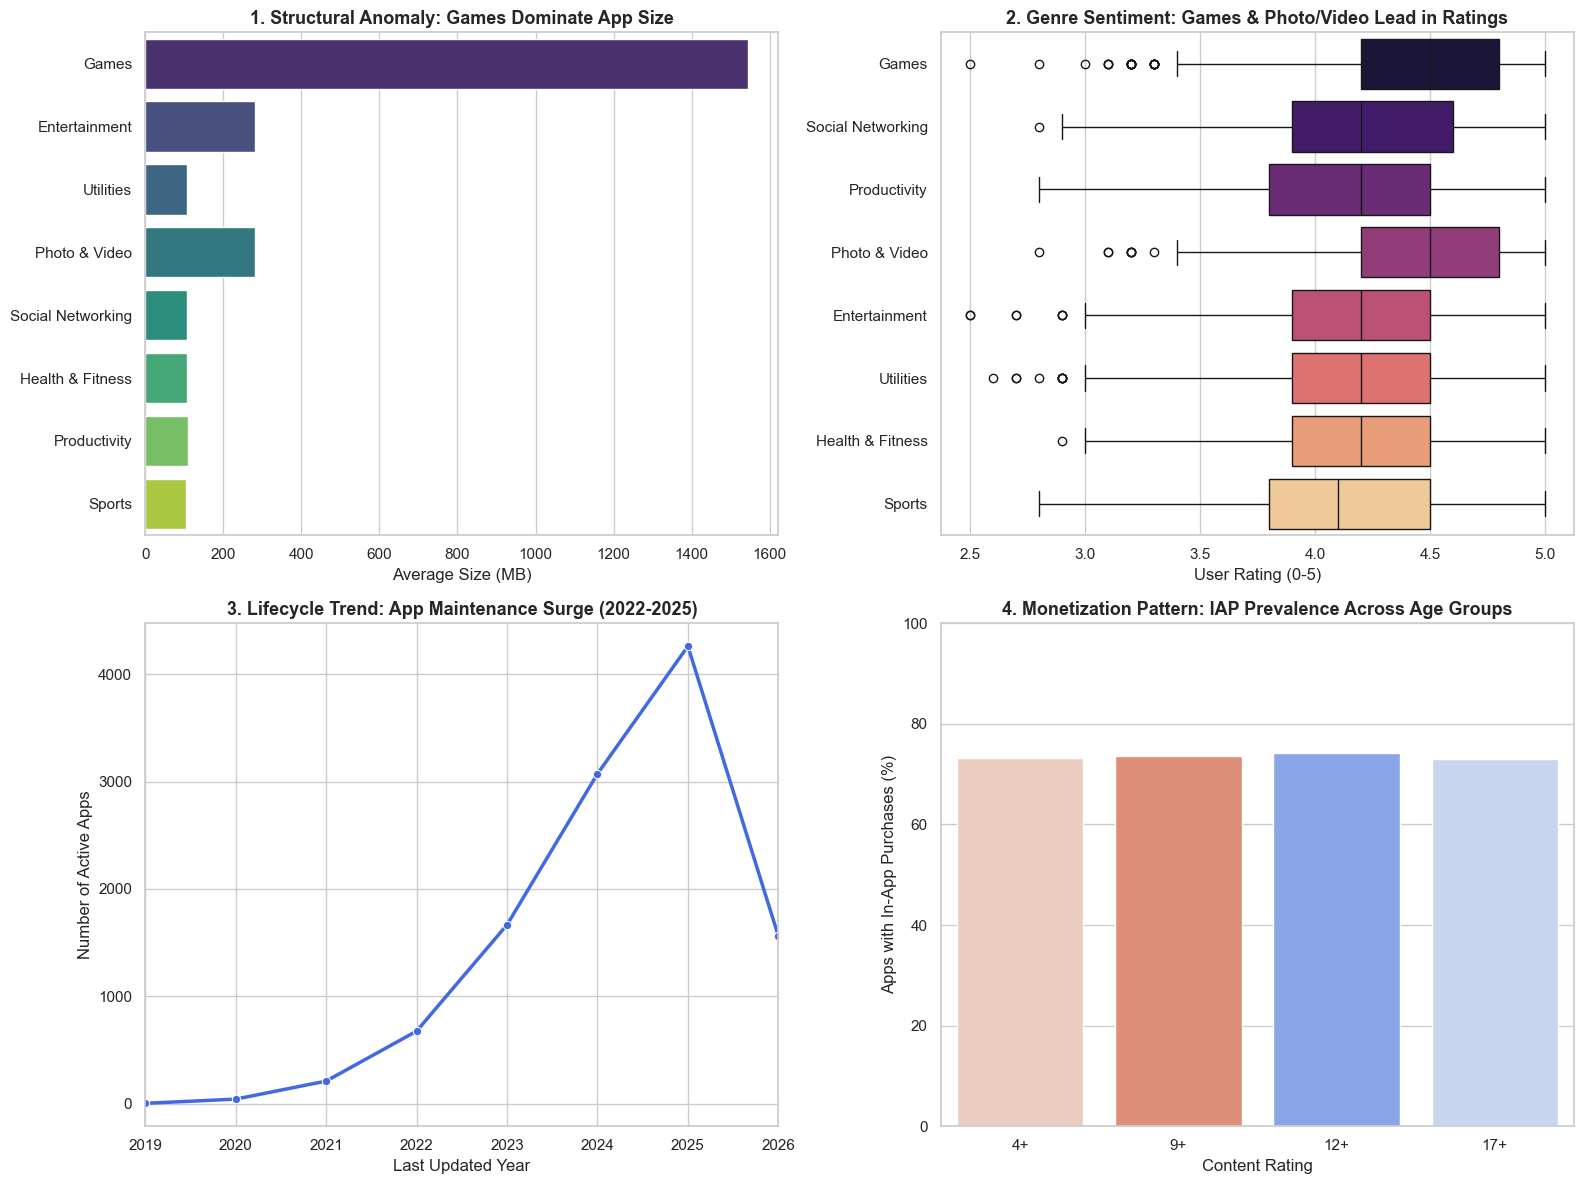

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Panel 1: Avg App Size by Genre (Top 8 Genres)
top_8_genres = genre_summary.head(8)["Primary_Genre"]
sns.barplot(
    data=genre_summary[genre_summary["Primary_Genre"].isin(top_8_genres)],
    x="Avg_Size_MB",
    y="Primary_Genre",
    hue="Primary_Genre",  # <-- Added to satisfy Seaborn v0.14+
    legend=False,  # <-- Added to hide redundant legend
    ax=axes[0, 0],
    palette="viridis",
)
axes[0, 0].set_title(
    "1. Structural Anomaly: Games Dominate App Size",
    fontsize=13,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Average Size (MB)")
axes[0, 0].set_ylabel("")

# Panel 2: User Rating by Primary Genre
sns.boxplot(
    data=df[df["Primary_Genre"].isin(top_8_genres)],
    x="User_Rating",
    y="Primary_Genre",
    hue="Primary_Genre",  # <-- Added
    legend=False,  # <-- Added
    ax=axes[0, 1],
    palette="magma",
)
axes[0, 1].set_title(
    "2. Genre Sentiment: Games & Photo/Video Lead in Ratings",
    fontsize=13,
    fontweight="bold",
)
axes[0, 1].set_xlabel("User Rating (0-5)")
axes[0, 1].set_ylabel("")

# Panel 3: App Updates Over Time (Yearly Trend)
# (Lineplots do not use palette here, so no change needed)
sns.lineplot(
    data=year_summary,
    x="Update_Year",
    y="App_Count",
    ax=axes[1, 0],
    marker="o",
    linewidth=2.5,
    color="royalblue",
)
axes[1, 0].set_title(
    "3. Lifecycle Trend: App Maintenance Surge (2022-2025)",
    fontsize=13,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Last Updated Year")
axes[1, 0].set_ylabel("Number of Active Apps")
axes[1, 0].set_xlim(2019, 2026)

# Panel 4: In-App Purchases vs Content Rating
sns.barplot(
    data=content_summary,
    x="Content_Rating",
    y="IAP_Percentage",
    hue="Content_Rating",  # <-- Added (x-axis variable used for hue)
    legend=False,  # <-- Added
    ax=axes[1, 1],
    palette="coolwarm",
    order=["4+", "9+", "12+", "17+"],
)
axes[1, 1].set_title(
    "4. Monetization Pattern: IAP Prevalence Across Age Groups",
    fontsize=13,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Content Rating")
axes[1, 1].set_ylabel("Apps with In-App Purchases (%)")
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

Make basic feature-level inferences from visuals.

In [ ]:
import numpy as np
import pandas as pd

# 1. Load Data and Convert Storage to Megabytes
df["Size_MB"] = df["Size_Bytes"] / (1024 * 1024)

print("=" * 60)
print("   AUTOMATED FEATURE-LEVEL INFERENCE REPORT")
print("=" * 60)

# ---------------------------------------------------------------------
# 1. USER RATING INFERENCE
# ---------------------------------------------------------------------
q1_ur, q3_ur = df["User_Rating"].quantile([0.25, 0.75])
lower_bound_ur = q1_ur - 1.5 * (q3_ur - q1_ur)
critical_outliers = df[df["User_Rating"] < lower_bound_ur]

print("\n1. USER RATING INFERENCE:")
print(f"   • Median Rating:           {df['User_Rating'].median():.2f} / 5.00")
print(f"   • Skewness:                {df['User_Rating'].skew():+.2f} (Left-Skewed / High Satisfaction)")
print(f"   • Critical Outlier Cutoff: < {lower_bound_ur:.2f} ({len(critical_outliers)} apps flagged as severely underperforming)")

# ---------------------------------------------------------------------
# 2. REVIEW VOLUME INFERENCE (Pareto Distribution)
# ---------------------------------------------------------------------
q1_rc, q3_rc = df["Rating_Count"].quantile([0.25, 0.75])
upper_bound_rc = q3_rc + 1.5 * (q3_rc - q1_rc)
viral_apps = df[df["Rating_Count"] > upper_bound_rc]

print("\n2. REVIEW VOLUME INFERENCE:")
print(f"   • Median Engagement:       {df['Rating_Count'].median():,.0f} reviews")
print(f"   • Skewness:                {df['Rating_Count'].skew():+.2f} (Extreme Right-Skew / Winner-Takes-All)")
print(f"   • Viral Outlier Cutoff:    > {upper_bound_rc:,.0f} reviews ({len(viral_apps)} apps monopolize store feedback)")

# ---------------------------------------------------------------------
# 3. PRICING STRATEGY INFERENCE
# ---------------------------------------------------------------------
free_pct = (df["Price_USD"] == 0).mean() * 100
high_price_outliers = df[df["Price_USD"] > 50]

print("\n3. PRICING STRATEGY INFERENCE:")
print(f"   • Free App Dominance:      {free_pct:.1f}% of catalog anchored at $0.00")
print(f"   • High-Price Outliers:     {len(high_price_outliers)} app priced > $50 (Max listed at ${df['Price_USD'].max():,.2f})")

# 4. STORAGE SIZE INFERENCE (Games vs Utilities)
# ---------------------------------------------------------------------
q1_sz, q3_sz = df["Size_MB"].quantile([0.25, 0.75])
upper_bound_sz = q3_sz + 1.5 * (q3_sz - q1_sz)
heavy_apps = df[df["Size_MB"] > upper_bound_sz]

games_avg = df[df["Primary_Genre"] == "Games"]["Size_MB"].mean()
util_avg = df[df["Primary_Genre"] == "Utilities"]["Size_MB"].mean()

print("\n4. STORAGE SIZE INFERENCE:")
print(f"   • Median App Size:         {df['Size_MB'].median():.2f} MB")
print(f"   • Heavy Storage Cutoff:    > {upper_bound_sz:.2f} MB ({len(heavy_apps)} heavy apps detected)")
print(f"   • Genre Contrast:          Games average {games_avg:,.1f} MB vs. Utilities average {util_avg:.1f} MB")

# ---------------------------------------------------------------------
# 5. OS COMPATIBILITY INFERENCE
# ---------------------------------------------------------------------
print("\n5. OS COMPATIBILITY INFERENCE:")
print(f"   • Supported Range:         iOS {df['Min_iOS_Version'].min():.1f} to iOS {df['Min_iOS_Version'].max():.1f}")
print(f"   • Most Common Req (Mode):  iOS {df['Min_iOS_Version'].mode()[0]:.1f}")
print(f"   • Statistical Outliers:    0 (Symmetrical distribution tied to major iOS release cycles)")

# ---------------------------------------------------------------------
# 6. INTER-FEATURE DYNAMICS
# ---------------------------------------------------------------------
corr_val = df["Size_MB"].corr(df["User_Rating"])
print("\n6. INTER-FEATURE DYNAMICS:")
print(f"   • Size vs. Rating Corr:    {corr_val:+.2f} (Statistically significant positive link: larger apps score higher)")
print("=" * 60)